In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
data = pd.read_excel("datasets.csv.xlsx")
data.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


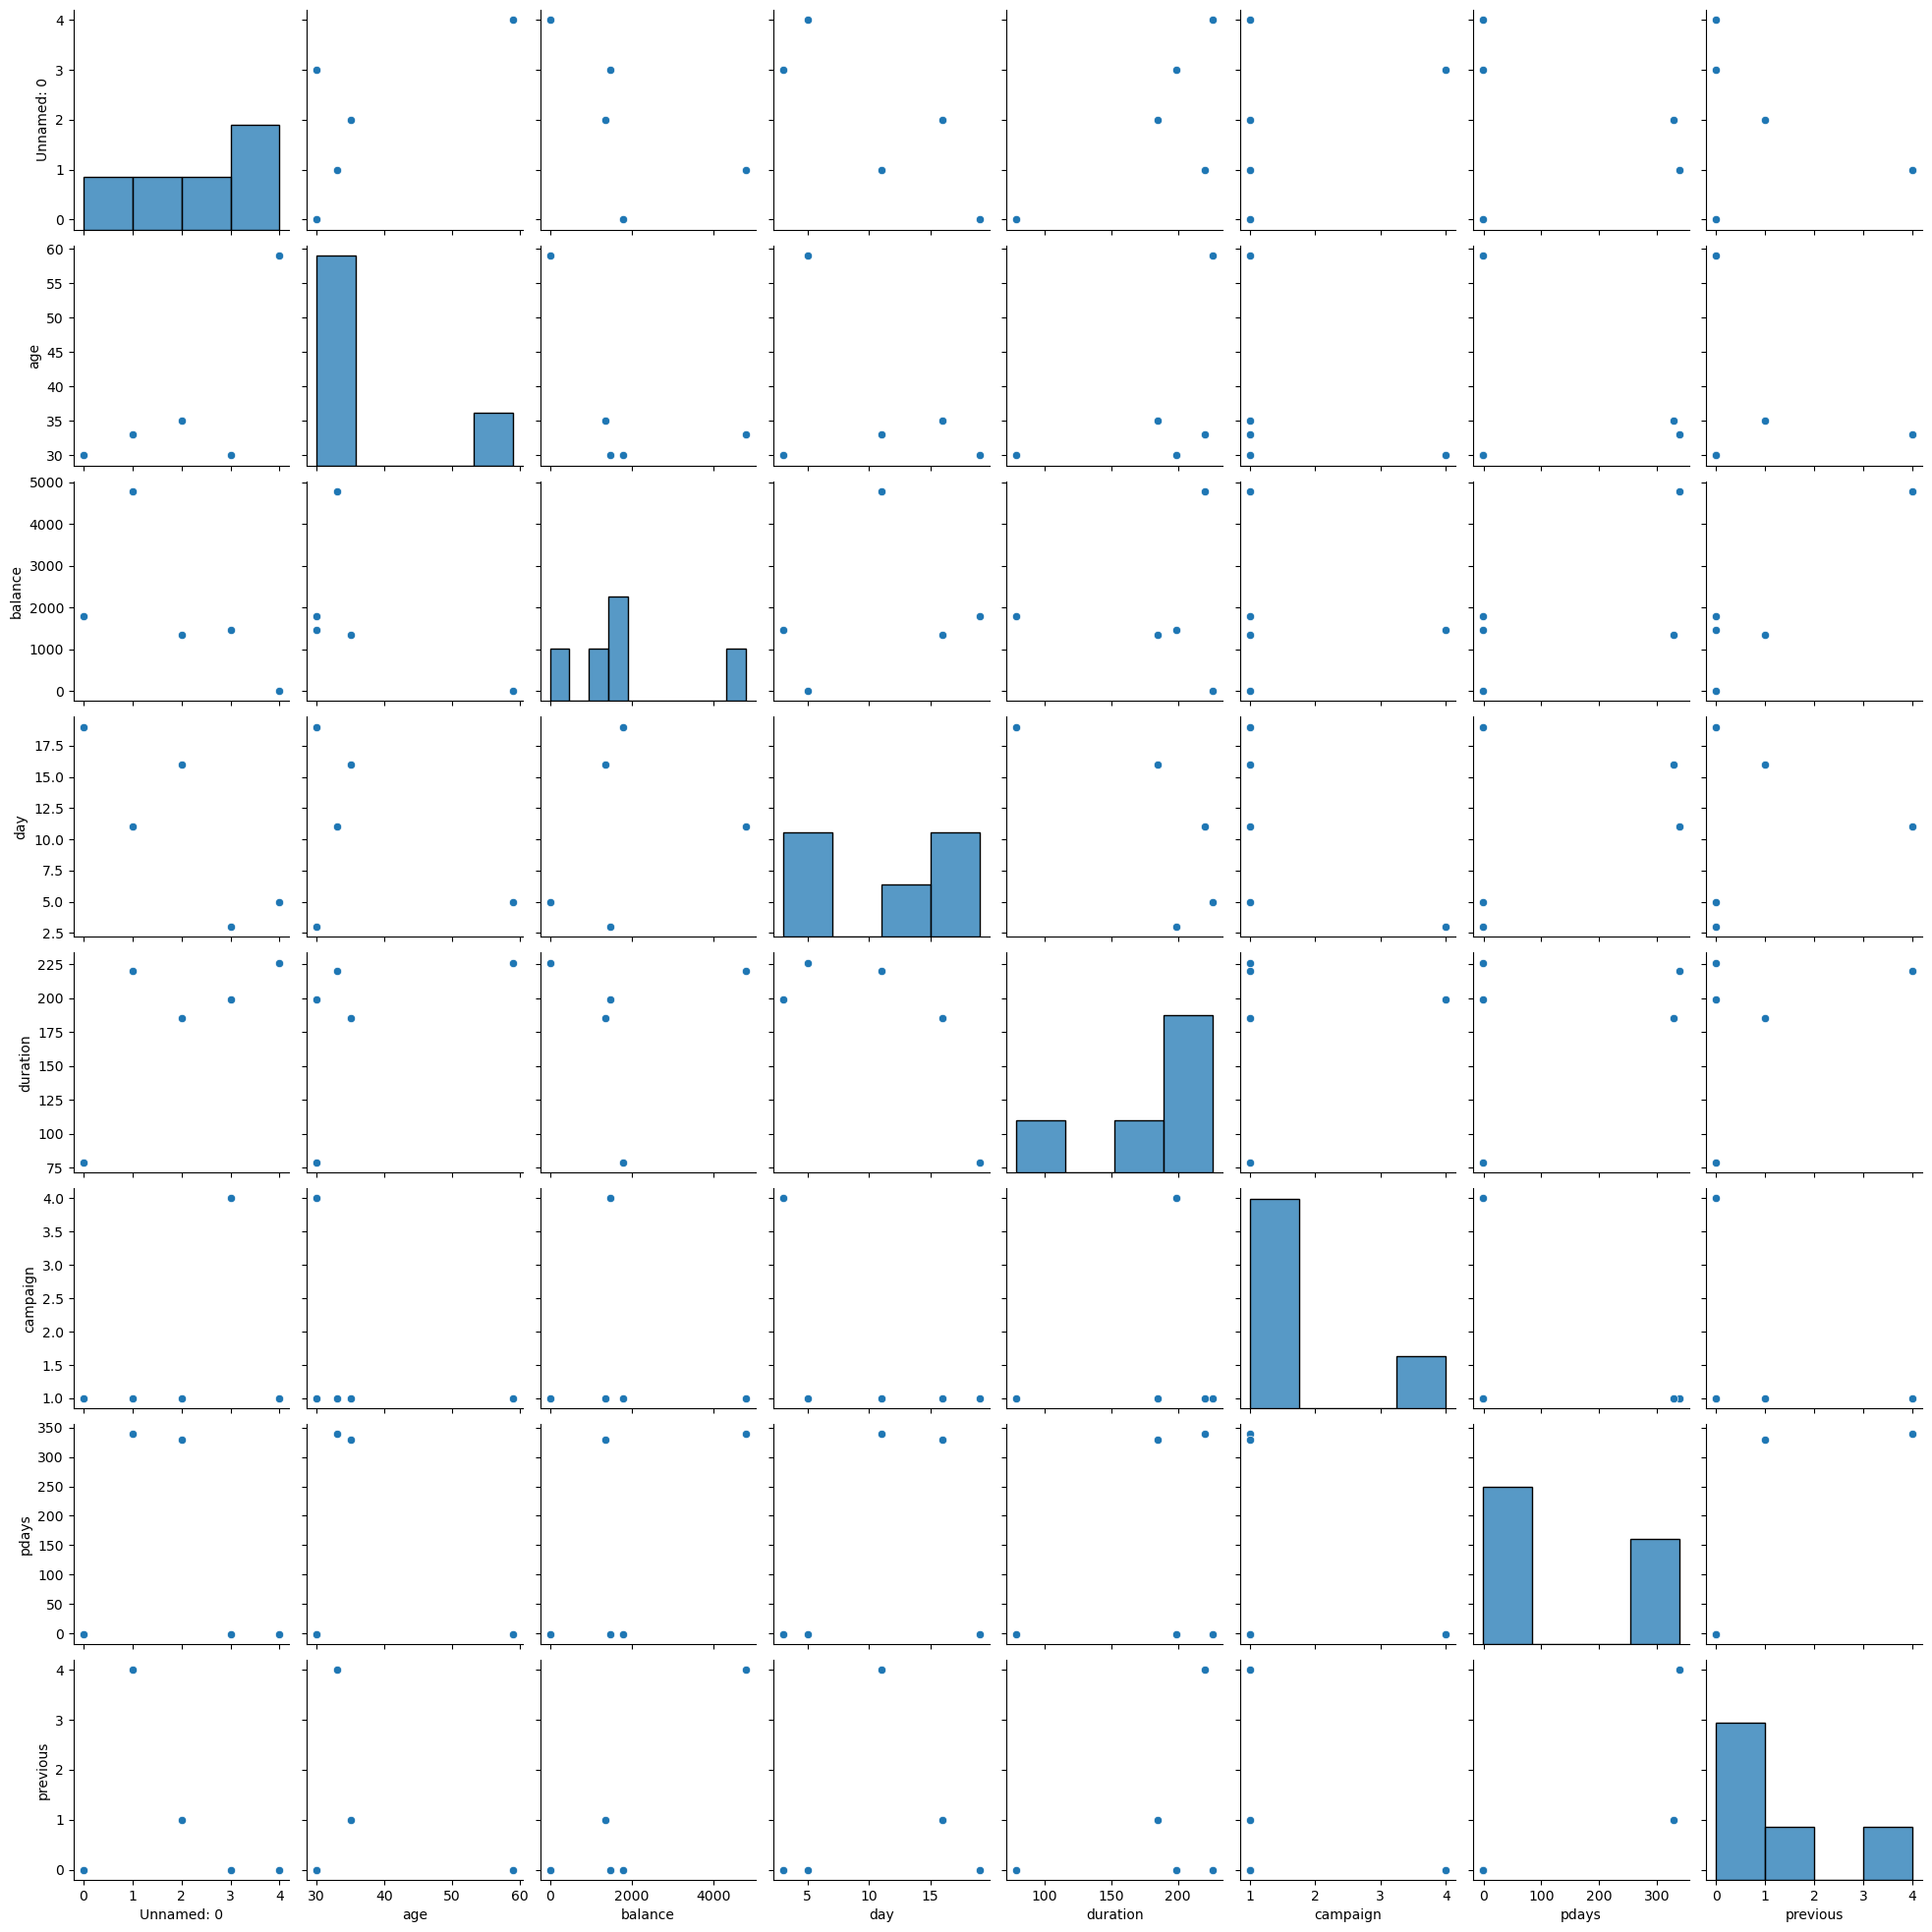

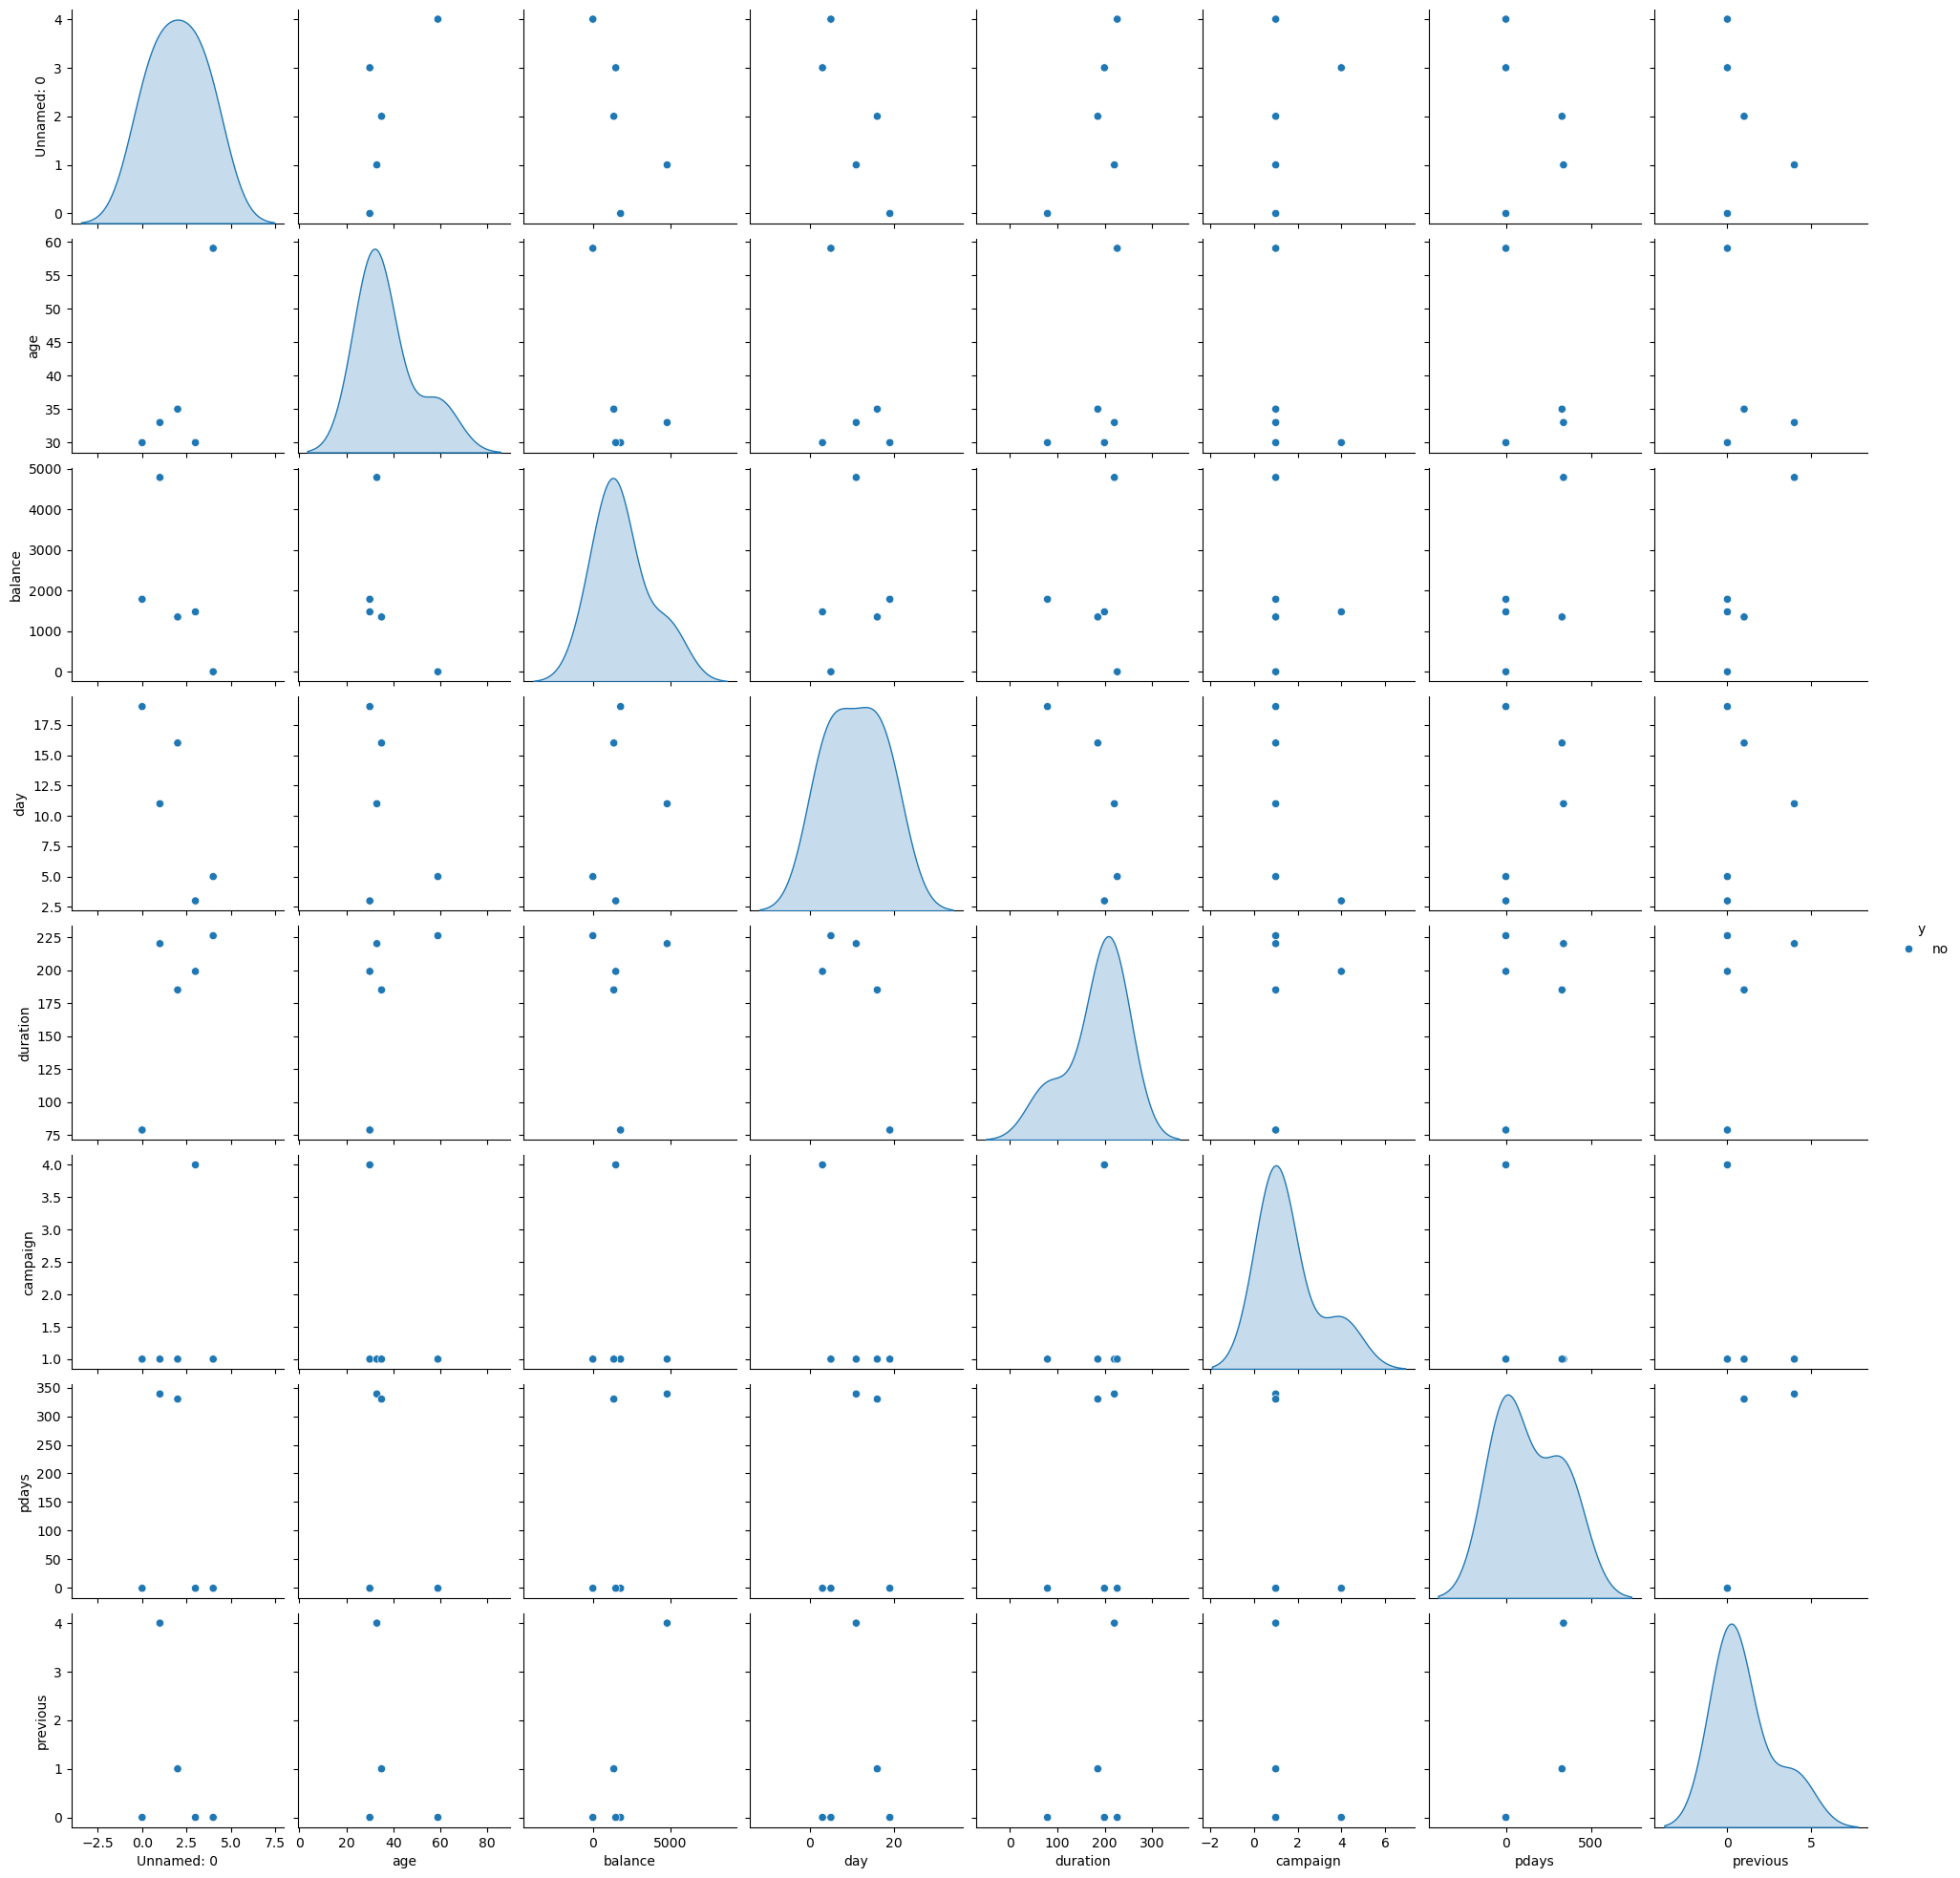

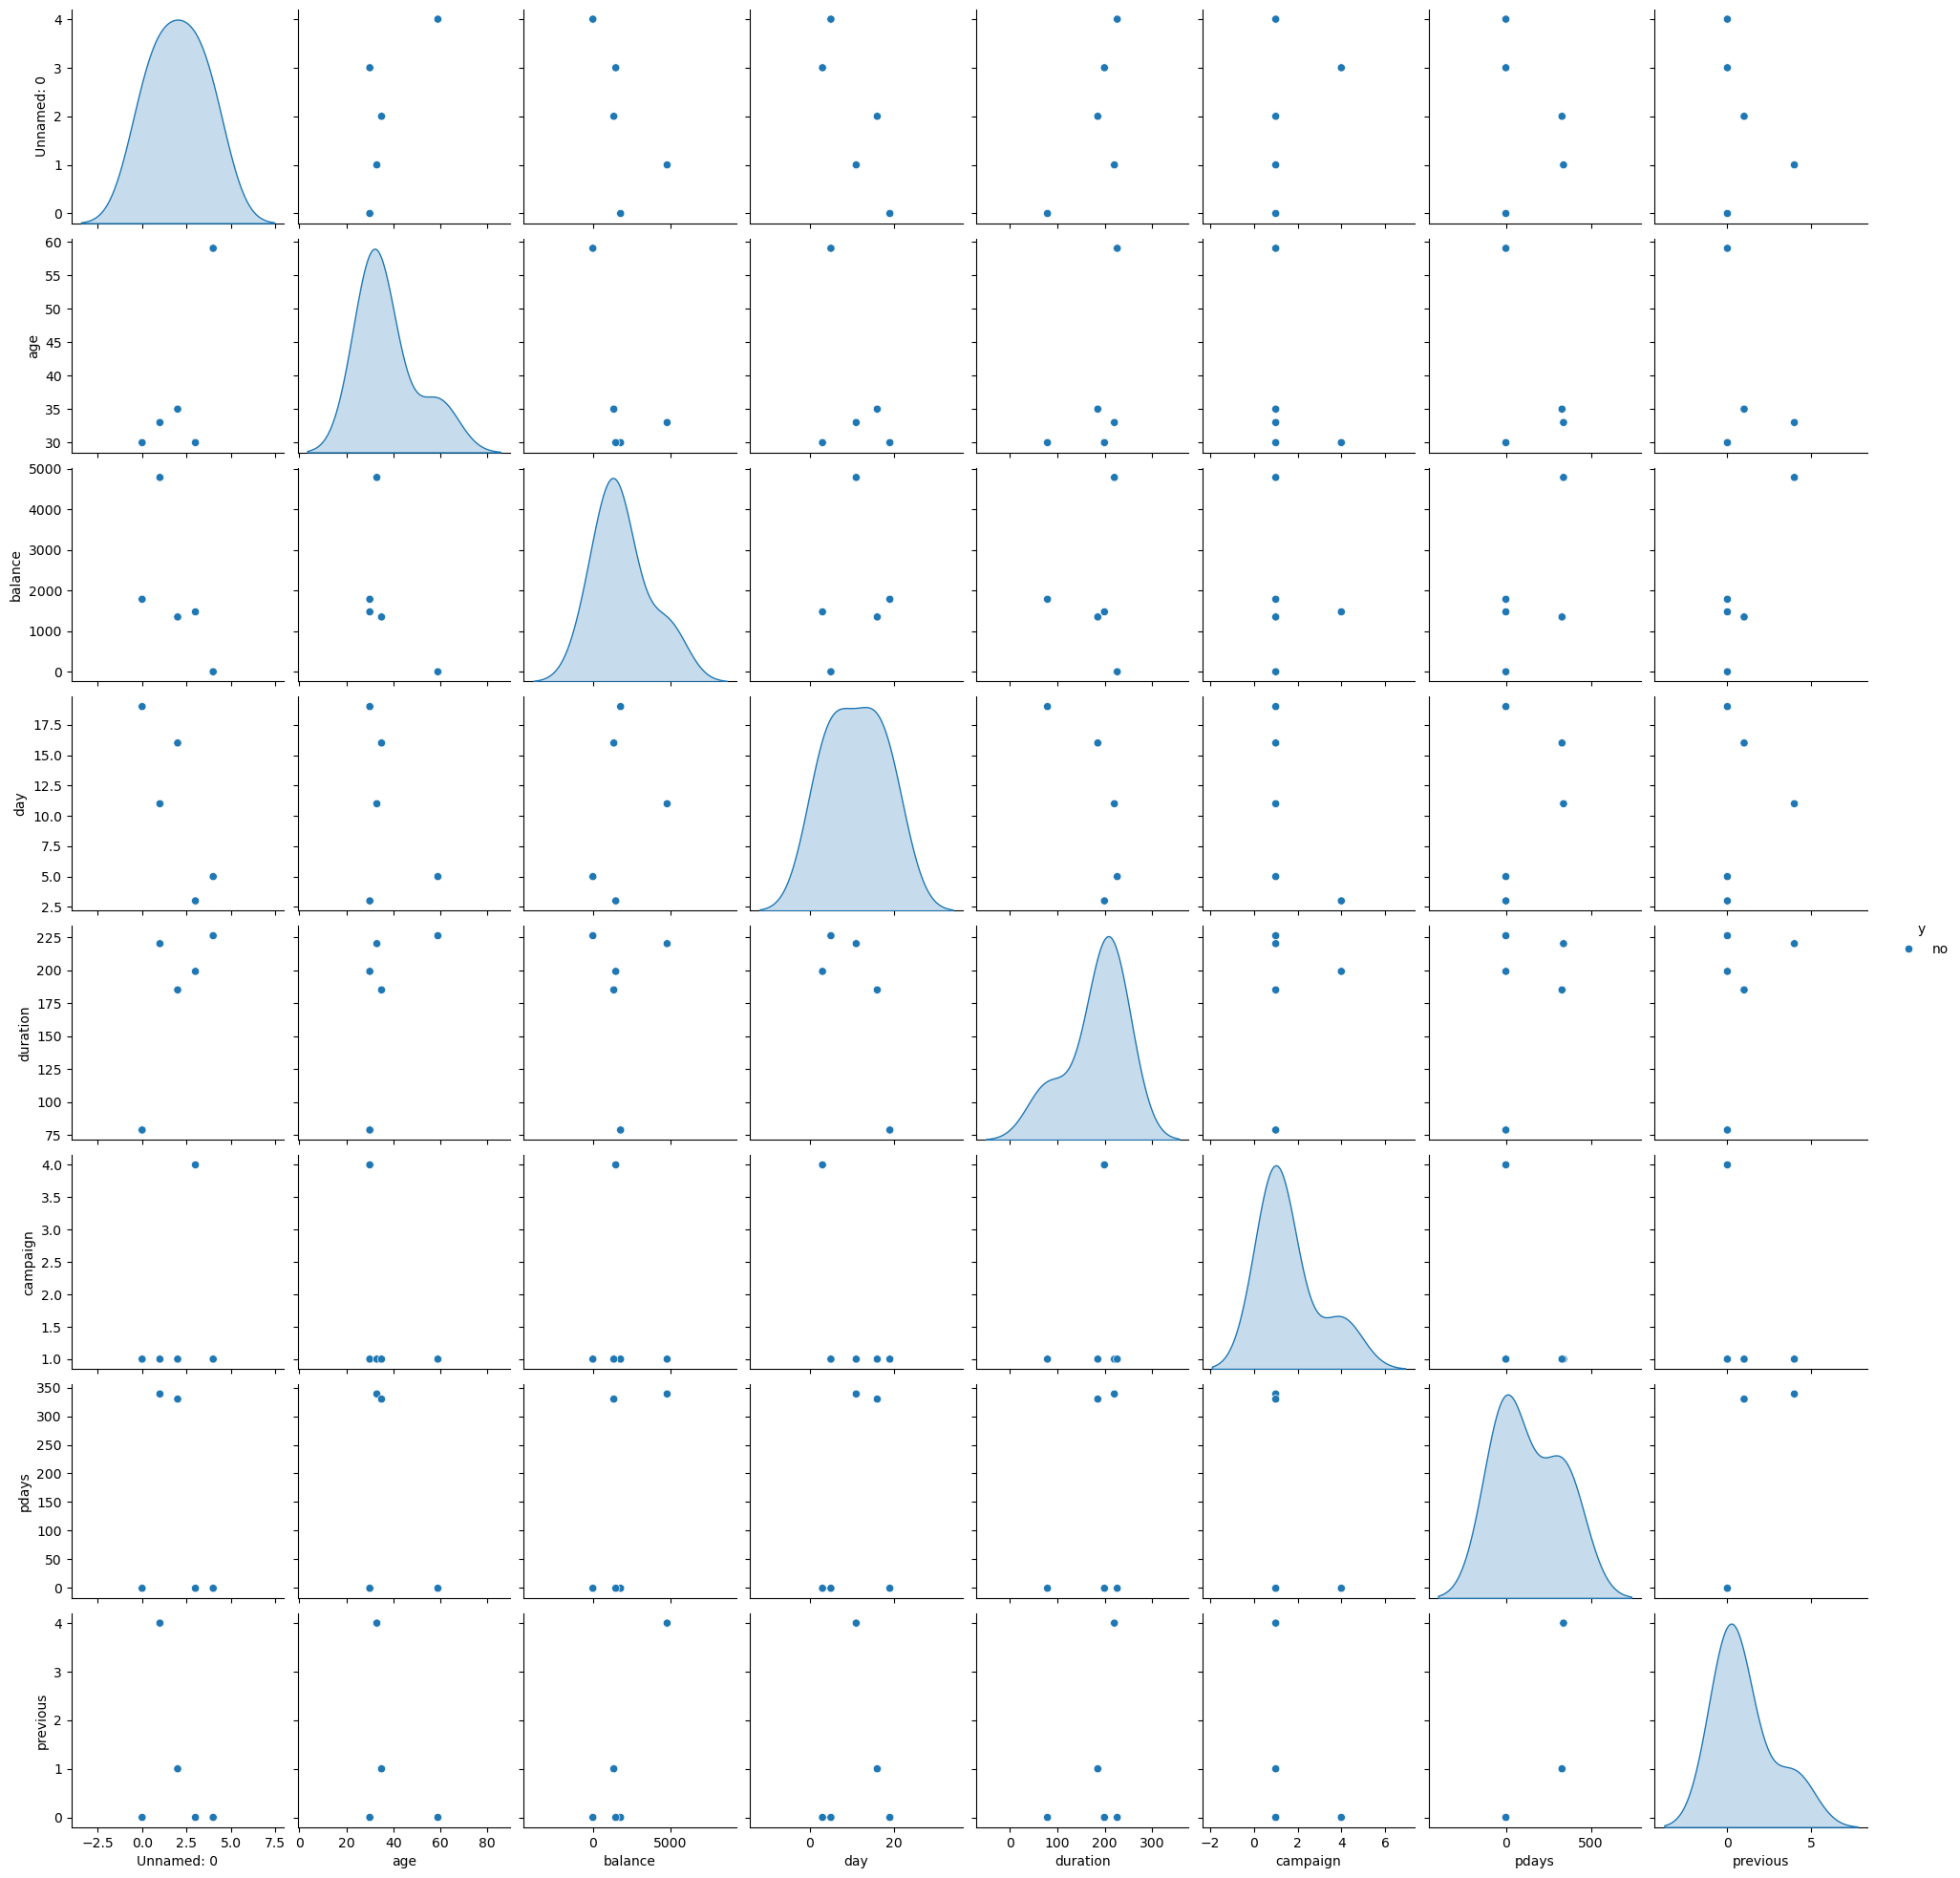

In [9]:
sns.pairplot(data, hue='y')
plt.show()

In [11]:
correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix)

            Unnamed: 0       age   balance       day  duration  campaign  \
Unnamed: 0    1.000000  0.709338 -0.617241 -0.828517  0.722263  0.353553   
age           0.709338  1.000000 -0.560118 -0.420294  0.481926 -0.337425   
balance      -0.617241 -0.560118  1.000000  0.229333  0.068629 -0.128142   
day          -0.828517 -0.420294  0.229333  1.000000 -0.736257 -0.634671   
duration      0.722263  0.481926  0.068629 -0.736257  1.000000  0.160885   
campaign      0.353553 -0.337425 -0.128142 -0.634671  0.160885  1.000000   
pdays        -0.292503 -0.254129  0.627134  0.354250  0.319723 -0.408187   
previous     -0.365148 -0.235467  0.908477  0.126055  0.376761 -0.322749   

               pdays  previous  
Unnamed: 0 -0.292503 -0.365148  
age        -0.254129 -0.235467  
balance     0.627134  0.908477  
day         0.354250  0.126055  
duration    0.319723  0.376761  
campaign   -0.408187 -0.322749  
pdays       1.000000  0.801053  
previous    0.801053  1.000000  


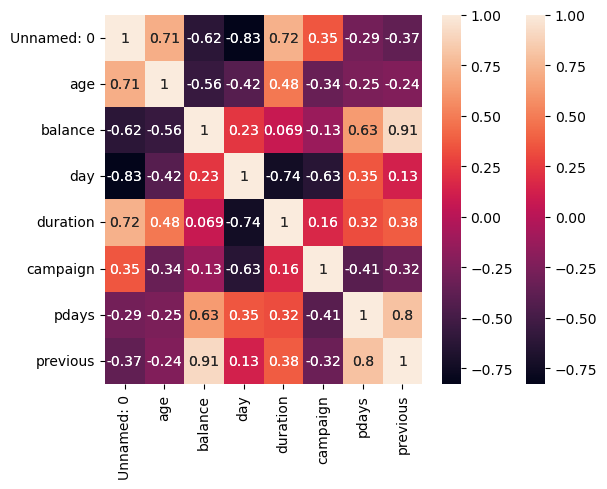

In [14]:
import matplotlib.pyplot  as plt
import seaborn as sns
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [15]:
data.dtypes

Unnamed: 0     int64
age            int64
job           object
marital       object
education     object
default       object
balance        int64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
y             object
dtype: object

In [19]:
data_new = pd.get_dummies(data,columns=['job','marital','education','default','housing','loan','contact','month','poutcome'])

In [22]:
data_new['y'] = data_new['y'].map({'yes': 1, 'no' : 0})

In [23]:
data_new.dtypes

Unnamed: 0               int64
age                      int64
balance                  int64
day                      int64
duration                 int64
campaign                 int64
pdays                    int64
previous                 int64
y                      float64
job_blue-collar           bool
job_management            bool
job_services              bool
job_unemployed            bool
marital_married           bool
marital_single            bool
education_primary         bool
education_secondary       bool
education_tertiary        bool
default_no                bool
housing_no                bool
housing_yes               bool
loan_no                   bool
loan_yes                  bool
contact_cellular          bool
contact_unknown           bool
month_apr                 bool
month_jun                 bool
month_may                 bool
month_oct                 bool
poutcome_failure          bool
poutcome_unknown          bool
dtype: object

In [24]:
print(data.shape)

(5, 18)


In [25]:
data.education.unique()

array(['primary', 'secondary', 'tertiary'], dtype=object)

In [26]:
pd.crosstab(index=data["education"], columns=data["y"])

y,no
education,
primary,1
secondary,2
tertiary,2


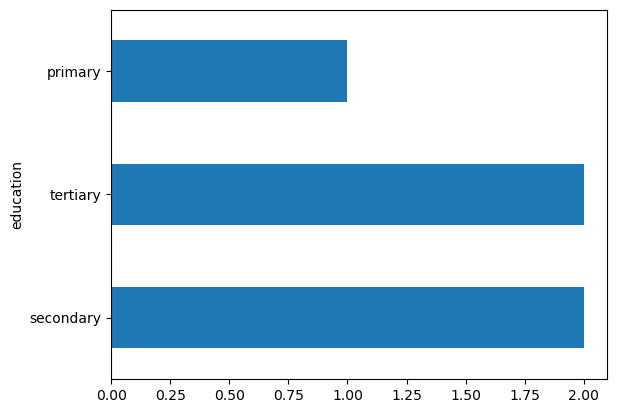

In [28]:
data.education.value_counts().plot(kind="barh")
plt.show()

In [53]:
data_y = pd.DataFrame(data_new['y'])
data_x = data_new.drop(['y'], axis=1)
print(data_x.columns)
print(data_y.columns)

Index(['Unnamed: 0', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous', 'job_blue-collar', 'job_management', 'job_services',
       'job_unemployed', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'default_no', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes',
       'contact_cellular', 'contact_unknown', 'month_apr', 'month_jun',
       'month_may', 'month_oct', 'poutcome_failure', 'poutcome_unknown'],
      dtype='object')
Index(['y'], dtype='object')


In [34]:
clf = LogisticRegression()

In [54]:
x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.3, random_state=2, stratify=data.y)
print (x_train.shape)
print (x_test.shape)
print (y_train.shape)
print (y_test.shape)

ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.